# Product Funnel & Growth Analytics for a Crypto Trading Platform

## 1. Business Context
This notebook studies end-to-end product analytics work for a centralized crypto trading platform. The objective is to understand user behavior across the product funnel, identify growth bottlenecks, define success metrics, and operationalize next steps through experimentation-ready analysis.

The focus is **product decision-making**, not price prediction.

## 2. Business Questions
- Where do users drop off between signup, KYC, first trade, and repeat trade?
- How does behavior differ between spot and derivatives traders?
- Which metrics best define product success and activation?
- What concrete actions should product teams take next?

## 3. Dataset Description
The dataset is a realistic synthetic simulation of user-level events for a crypto exchange funnel. It reflects common industry patterns such as KYC friction and higher engagement among derivatives traders.

**Key columns**:
- user_id
- signup, kyc_completed, first_trade, repeat_trade (binary)
- trade_type (spot / derivatives)
- signup_date, trade_date

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 4)

## 4. Load Data

In [2]:
df = pd.read_csv('crypto_user_funnel.csv')
df.head()

,user_id,signup,kyc_completed,first_trade,repeat_trade,trade_type,signup_date,trade_date
0,1,1,1,0,0,NaN,2024-01-15,NaN
1,2,1,0,0,0,NaN,2024-04-18,NaN
2,3,1,0,0,0,NaN,2024-04-25,NaN
3,4,1,1,0,0,NaN,2024-04-01,NaN
4,5,1,1,0,0,NaN,2024-05-17,NaN


## 5. Data Quality Checks

In [3]:
df.info()
df.isnull().mean()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   user_id        2000 non-null   int64
 1   signup         2000 non-null   int64
 2   kyc_completed  2000 non-null   int64
 3   first_trade    2000 non-null   int64
 4   repeat_trade   2000 non-null   int64
 5   trade_type     645 non-null    str  
 6   signup_date    2000 non-null   str  
 7   trade_date     645 non-null    str  
dtypes: int64(5), str(3)
memory usage: 125.1 KB


user_id          0.0000
signup           0.0000
kyc_completed    0.0000
first_trade      0.0000
repeat_trade     0.0000
trade_type       0.6775
signup_date      0.0000
trade_date       0.6775
dtype: float64

## 6. Funnel Construction (User-Level)

In [4]:
funnel = (
    df.groupby('user_id')
      .agg({
          'signup': 'max',
          'kyc_completed': 'max',
          'first_trade': 'max',
          'repeat_trade': 'max'
      })
)

funnel.sum()

signup           2000
kyc_completed    1439
first_trade       645
repeat_trade      356
dtype: int64

## 7. Funnel Conversion Rates

In [5]:
steps = funnel.sum()
conversion_rates = steps / steps.shift(1)

pd.DataFrame({
    'users': steps,
    'conversion_rate': conversion_rates
})

,users,conversion_rate
signup,2000,NaN
kyc_completed,1439,0.719500
first_trade,645,0.448228
repeat_trade,356,0.551938


## 8. Funnel Visualization

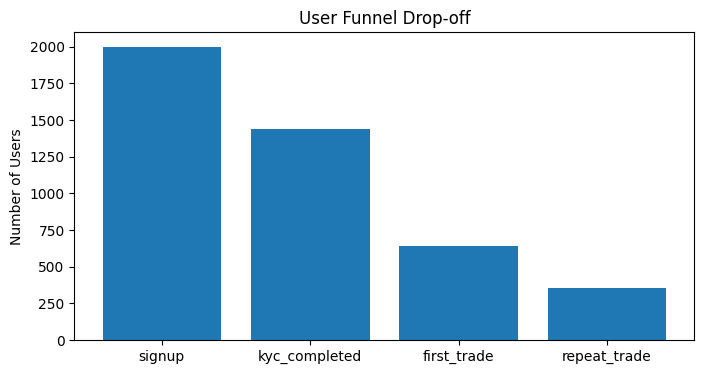

In [6]:
plt.bar(steps.index, steps.values)
plt.title('User Funnel Drop-off')
plt.ylabel('Number of Users')
plt.show()

## 9. Spot vs Derivatives Adoption

In [7]:
trade_type_summary = (
    df[df['first_trade'] == 1]
      .groupby('trade_type')['user_id']
      .nunique()
)

trade_type_summary

trade_type
derivatives    193
spot           452
Name: user_id, dtype: int64

## 10. Retention (Repeat Trade Rate)

In [8]:
retention_by_type = (
    df[df['first_trade'] == 1]
      .groupby('trade_type')['repeat_trade']
      .mean()
)

retention_by_type

trade_type
derivatives    0.523316
spot           0.564159
Name: repeat_trade, dtype: float64

## 11. Activation Metric: Time to First Trade

In [9]:
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['trade_date'] = pd.to_datetime(df['trade_date'])

activation_df = df[df['first_trade'] == 1].copy()
activation_df['time_to_first_trade'] = (
    activation_df['trade_date'] - activation_df['signup_date']
).dt.days

activation_df['time_to_first_trade'].describe()

count    645.000000
mean       7.286822
std        3.719167
min        1.000000
25%        4.000000
50%        7.000000
75%       10.000000
max       13.000000
Name: time_to_first_trade, dtype: float64

## 12. Activation Speed Distribution

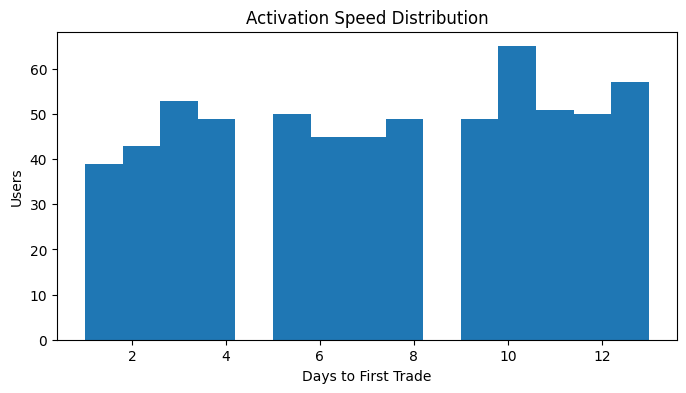

In [10]:
plt.hist(activation_df['time_to_first_trade'], bins=15)
plt.xlabel('Days to First Trade')
plt.ylabel('Users')
plt.title('Activation Speed Distribution')
plt.show()

## 13. Key Product KPIs Defined
- Signup → KYC conversion
- KYC → First trade conversion (activation)
- Time to first trade
- Repeat trade rate
- Derivatives adoption rate

## 14. Business Insights
- The largest drop-off occurs between KYC completion and first trade, indicating activation friction.
- Derivatives traders represent a smaller but more engaged segment with higher repeat rates.
- Faster activation correlates with higher repeat engagement.
- Product growth should prioritize onboarding clarity and early confidence-building.

## 15. Next Steps – Operationalized

In [11]:
experiment_metrics = {
    'Primary Metric': 'First Trade Conversion Rate',
    'Secondary Metric': 'Time to First Trade',
    'Guardrail Metrics': ['Repeat Trade Rate', 'Post-KYC Drop-off']
}

experiment_metrics

{'Primary Metric': 'First Trade Conversion Rate',
 'Secondary Metric': 'Time to First Trade',
 'Guardrail Metrics': ['Repeat Trade Rate', 'Post-KYC Drop-off']}

In [12]:
# Revenue proxy using repeat trades
revenue_proxy = df.groupby('trade_type')['repeat_trade'].sum()
revenue_proxy

trade_type
derivatives    101
spot           255
Name: repeat_trade, dtype: int64

### Product Actions
- Launch A/B tests on onboarding flows between KYC and first trade
- Introduce educational prompts and risk disclosures
- Invest in derivatives onboarding for high-intent users
- Monitor guardrail metrics to prevent harmful behavior

## 16. Final Note
This notebook demonstrates end-to-end product analytics ownership: from funnel construction and KPI definition to experiment-ready insights and concrete product actions. It mirrors how product data teams should operate in real-world trading platforms.